In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from itertools import permutations

def euclid_distance(p1: np.ndarray, p2: np.ndarray) -> float:
    """
    takes two points p1, p2 as two ndarrays of length d (d: dimension) 
    and calculates the euclidean distance between the two points
    returns distance as float value
    """
    return np.sqrt(np.sum(np.square(p1 - p2)))

def tsp_length(nodes_array: np.ndarray) -> float:
    """
    calculate the length of the tsp traveling distance
    
    :param nodes_array: (sorted) array of coordinates of the N nodes
    :type nodes_array: np.ndarray (N, d)
    :return: total traveling distance
    :rtype: float
    """
    # calculate the pairwise differences between two consecutive nodes, keep in mind to return to start
    differences = nodes_array - np.roll(nodes_array, shift=-1, axis=0)
    # calculate individual distances and sum up
    distances = np.sqrt(np.sum(np.square(differences), axis=1))
    return np.sum(distances)

def polar_to_cartesian(r: float, theta: float) -> np.ndarray:
    """
    convert polar coordinates to cartesian coordinates
    
    :param r: radius
    :type r: float
    :param theta: angle in radians
    :type theta: float
    :return: cartesian coordinates as ndarray [x, y]
    :rtype: np.ndarray
    """
    x = r * np.cos(theta)
    y = r * np.sin(theta)
    return np.column_stack([x, y])

def cartesian_to_polar(x: float, y: float) -> np.ndarray:
    """
    convert cartesian coordinates to polar coordinates
    
    :param x: x coordinate
    :type x: float
    :param y: y coordinate
    :type y: float
    :return: polar coordinates as ndarray [r, theta]
    :rtype: np.ndarray
    """
    r = np.sqrt(x**2 + y**2)
    theta = np.arctan2(y, x)
    return np.column_stack([r, theta])



In [52]:
# define N nodes, uniformly spaced around a circle
N = 8
R = 1
phi = np.array([2 * np.pi * i / N for i in range(0,N)])

nodes = polar_to_cartesian(R, phi)

# brute force TSP solution
# always start and end at node 0
# get all permutations of the nodes excluding the first one
node_indices = list(range(1, N))
perms = permutations(node_indices)
tours = nodes[np.array([[0] + list(p) + [0] for p in perms])]
lengths = np.array([tsp_length(tour) for tour in tours])
min_index = np.argmin(lengths)
min_length = lengths[min_index]

print(f"Minimum traveling distance: {min_length:4f}")



Minimum traveling distance: 6.122935


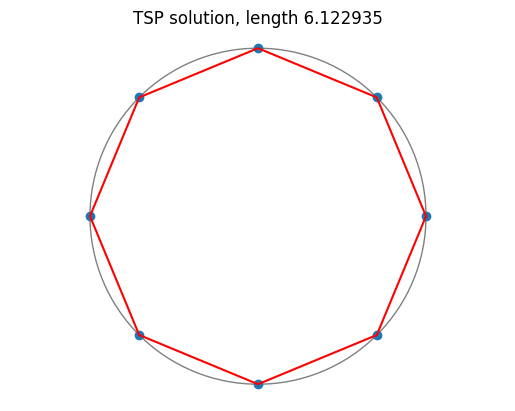

In [55]:
# plot results
plt.figure()
plt.title(f"TSP solution, length {min_length:4f}")

plt.axis('equal')
plt.axis('off')
plt.grid(False)

circle = plt.Circle((0, 0), R, color='gray', fill=False)
plt.gca().add_artist(circle)
plt.scatter(nodes[:, 0], nodes[:,1])
plt.plot(tours[min_index][:, 0], tours[min_index][:, 1], 'r-')
plt.show()

want_a_lot_of_plots = False
if want_a_lot_of_plots:
    for tour in tours[::]:
        plt.figure()
        plt.axis('equal')
        plt.axis('off')
        plt.grid(False)

        circle = plt.Circle((0, 0), R, color='gray', fill=False)
        plt.gca().add_artist(circle)
        plt.scatter(nodes[:, 0], nodes[:,1])
        plt.plot(tour[:, 0], tour[:, 1], 'b-', alpha=0.1)
        plt.show()